# Εργασία 10 – Clustering

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Read Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/spotify_dataset.csv")
df = df.rename(columns={'Unnamed: 0': 'Number'})
df

,Number,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


## 1. Process each dataframe as follows:
a. Remove the attributes (Number, Track Id, Artists, Album Name, Track Name) from
them and keep them in a separate dataframe, as you will find below.

b. Apply One-Hot Encoding to Genres.

In [ ]:
# Remove the attributes
drop_cols = ['Number', 'track_id', 'artists', 'album_name', 'track_name']
# Store cols in new df
df_new = df[drop_cols]
# drop them from the main df
df = df.drop(drop_cols, axis=1)


In [ ]:
# Apply one hot encoding to genres
encoder = OneHotEncoder(sparse_output=False)

# fit the column data
one_hot_encoded = encoder.fit_transform(df[['track_genre']])

# Create DF after encoding
one_hot_df = pd.DataFrame(one_hot_encoded,
                          columns=encoder.get_feature_names_out(['track_genre']))

one_hot_cols = one_hot_df.columns # Save the columns (might need)

# Concat the results
genre = df['track_genre']
df = pd.concat([df, one_hot_df], axis=1)
df= df.drop('track_genre', axis=1)
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# df will be used to normilize
temp = df.drop(['mode', 'explicit'], axis=1)
temp = temp.drop(one_hot_df, axis=1)
temp

,popularity,duration_ms,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0.172,0.2350,5,-16.393,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,22,385000,0.174,0.1170,0,-18.318,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,22,271466,0.629,0.3290,0,-10.895,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,41,283893,0.587,0.5060,7,-10.889,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


## 2. Normalize the features appropriately.

In [ ]:
# Normilize all data except binary ones (mode, all encoded columns, explicit)
scaler = MinMaxScaler()

normed_data = scaler.fit_transform(temp)
normed_data = pd.DataFrame(normed_data, columns=temp.columns)

# Drop non nomrilized data and concat df
df = df.drop(temp.columns, axis=1)
df = pd.concat([df, normed_data], axis=1)
df

,explicit,mode,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,...,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,False,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.4610,0.090909,0.791392,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,0.8
1,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1660,0.090909,0.597377,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,0.8
2,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.3590,0.000000,0.736123,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,0.8
3,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0596,0.000000,0.573701,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,0.6
4,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.4430,0.181818,0.737103,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.2350,0.454545,0.612952,0.043731,0.642570,0.928000,0.0863,0.034070,0.517705,1.0
113996,False,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1170,0.000000,0.577345,0.041554,0.997992,0.976000,0.1050,0.035176,0.350242,0.8
113997,False,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.3290,0.000000,0.714648,0.043523,0.870482,0.000000,0.0839,0.746734,0.543933,0.8
113998,False,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5060,0.636364,0.714759,0.030777,0.382530,0.000000,0.2700,0.415075,0.558651,0.8


## 3. Apply the K-Means algorithm for 𝑘 = {2, 3, 5, 7, 10, 15, 20}. You can consult the K-Means documentation to tweak any other parameter you want: K-Means. For each k, calculate the metric 𝑆𝑆𝐸 and then create a Line-Plot with k

In [ ]:
k_list = [2, 3, 5, 7, 10, 15, 20]

sse_list = []

# For every k store the sse metrice results
for k in k_list:
  kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(df)
  sse_list.append(kmeans.inertia_)

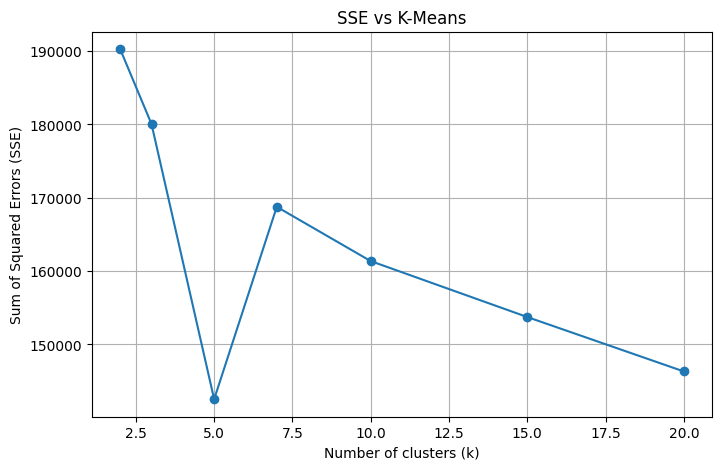

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_list, sse_list, marker='o')
plt.title('SSE vs K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

## 4. Choose the 𝑘 that best groups the data, according to the Elbow Method, and calculate the clusters of the music tracks (labels_)

In [ ]:
best_k = 5

# Train the model get the predicted clusters
best_kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=10).fit(df)
labels = best_kmeans.fit_predict(df) # same with best_kmeans.labels_


In [ ]:
best_kmeans

KMeans(n_clusters=5, n_init=10, random_state=0)

## 5. For each cluster, calculate the percentage of the dominant genre of the tracks and create a corresponding bar chart.

In [ ]:
# Create a df with culsters and genre (save in step 1)
results_df = pd.DataFrame({
    'cluster': labels,
    'track_genre': genre
})
results_df

,cluster,track_genre
0,0,acoustic
1,3,acoustic
2,1,acoustic
3,3,acoustic
4,3,acoustic
...,...,...
113995,3,world-music
113996,2,world-music
113997,2,world-music
113998,1,world-music


In [ ]:
# Calculate percentage of genre in clusters
gen_per = results_df.groupby('cluster')['track_genre'].value_counts(normalize=True).unstack(fill_value=0)

# Find dominant genre
dom_genre = gen_per.idxmax(axis=1) # genre with the max percentage
dom_per = gen_per.max(axis=1)*100 # max percentage

print("Dominant genre in each cluster")
print(dom_genre)
print("\n\nDominant percentage in genre (%)")
print(dom_per)

Dominant genre in each cluster
cluster
0    drum-and-bass
1        power-pop
2          romance
3       honky-tonk
4           comedy
dtype: object


Dominant percentage in genre (%)
cluster
0    1.810050
1    1.637937
2    7.018338
3    3.764148
4    6.754530
dtype: float64


### Create the figure

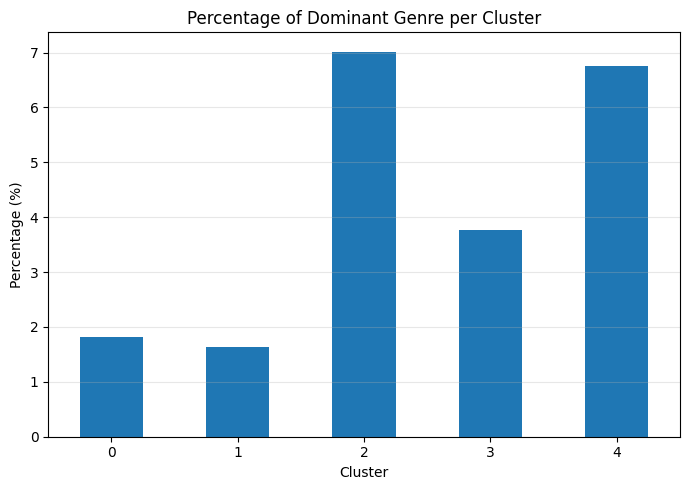

In [ ]:
plt.figure(figsize=(7, 5))

dom_per.plot(kind='bar')
plt.title('Percentage of Dominant Genre per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Choose 1 song you like. Mention the title, artist and cluster it belongs to. Then, suggest the Top-3 similar songs, calculating the Euclidean distance of the song with the rest of the songs in the Cluster it belongs to and choose the 3 with the smallest distance (Euclidean Distance). Mention which songs are suggested, as well as whether (in your opinion) they match the song you chose

In [ ]:
song = df_new[df_new['track_name'] == 'Calm Me Down']
song_idx = song.index[0]
song_row = df_new.loc[song_idx]

# Find the cluster
song_cluster = int(best_kmeans.predict(df.loc[[song_idx]])[0])

# print results
print("Song:")
print("Title:", song_row["track_name"])
print("Artist:", song_row["artists"])
print("Cluster:", song_cluster)

# Crate a mask which songs is in the same cluster with my choice
cluster_mask = (labels == song_cluster)

# Apply mask to dataset
cluster_indices = df.index[cluster_mask]
X_cluster = df.loc[cluster_indices]

# Calc Eucl distance
distance = pairwise_distances(
    X_cluster,
    df.loc[[song_idx]],
    metric="euclidean"
).ravel()

# Create a df with calculated distances
dist_df = pd.DataFrame({"index": cluster_indices, "distance": distance}).set_index("index")

# Drop my song from df
dist_df = dist_df.drop(index=song_idx)

# Get indexes of smallest distances (set limit to 3)
top3_idx = dist_df.nsmallest(3, "distance").index
found = df_new.loc[top3_idx, ["track_name", "artists", "album_name"]].copy() # make a copy to be safe df not be linked

# Create an extra column for calculated distances
found['distance'] = dist_df.loc[top3_idx, "distance"].values

print("The top 3 recomended songs be chosen by the model are:")
found



Song:
Title: Calm Me Down
Artist: Zack Tabudlo
Cluster: 1
The top 3 recomended songs be chosen by the model are:


,track_name,artists,album_name,distance
index,,,,
253,Rain - Long Ver.,Motohiro Hata,言ノ葉,0.212789
304,Closer,Boyce Avenue;Sarah Hyland,"Cover Sessions, Vol. 4",0.237976
375,明日の☆SHOW,Masaharu Fukuyama,残響,0.263214


## 7. Repeat query 6, using Cosine Distance (1 – Cosine Similarity) as the distance metric and check if the recommendations are better.


Answer: The recomendetions was the exact same with different distance values

In [ ]:
song = df_new[df_new['track_name'] == 'Calm Me Down']
song_idx = song.index[0]
song_row = df_new.loc[song_idx]

# Find the cluster
song_cluster = int(best_kmeans.predict(df.loc[[song_idx]])[0])

# print results
print("Song:")
print("Title:", song_row["track_name"])
print("Artist:", song_row["artists"])
print("Cluster:", song_cluster)

# Crate a mask which songs is in the same cluster with my choice
cluster_mask = (labels == song_cluster)

# Apply mask to dataset
cluster_indices = df.index[cluster_mask]
X_cluster = df.loc[cluster_indices]

# Calc Cosine distance
distance = cosine_distances(X_cluster, df.loc[[song_idx]]).ravel()

# Create a df with calculated distances
dist_df = pd.DataFrame({"index": cluster_indices, "distance": distance}).set_index("index")

# Drop my song from df
dist_df = dist_df.drop(index=song_idx)

# Get indexes of smallest distances (set limit to 3)
top3_idx = dist_df.nsmallest(3, "distance").index
found = df_new.loc[top3_idx, ["track_name", "artists", "album_name"]].copy() # make a copy to be safe df not be linked

# Create an extra column for calculated distances
found['distance'] = dist_df.loc[top3_idx, "distance"].values

print("The top 3 recomended songs be chosen by the model are:")
found



Song:
Title: Calm Me Down
Artist: Zack Tabudlo
Cluster: 1
The top 3 recomended songs be chosen by the model are:


,track_name,artists,album_name,distance
index,,,,
253,Rain - Long Ver.,Motohiro Hata,言ノ葉,0.003910
304,Closer,Boyce Avenue;Sarah Hyland,"Cover Sessions, Vol. 4",0.005056
375,明日の☆SHOW,Masaharu Fukuyama,残響,0.006097


## 8. Apply dbscan (or a faster variant of it, such as hdbscan) to cluster the data. Compare the number of clusters proposed with queries 4 and 8.

K-mean: 5

HDBSCAN Clusters: 133

K means is better to find the best song between few songs.
On the other hand can find bigger clusters with multiple smaller clusters. They are for more details (sub songs of the suggested songs)

In [ ]:
hdb = HDBSCAN(min_cluster_size=200)
labels_hdb = hdb.fit_predict(df)

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
print(f"HDBSCAN Clusters: {n_clusters_hdb}")


HDBSCAN Clusters: 133
